# NYC Schools SAT Score Analysis

## Table of Contents

**Part 1: Research Context**
1. [Research Question](#1-research-question)
2. [Data Sources](#2-data-sources)

**Part 2: Data Preparation**

3. [Configuration & Imports](#3-configuration--imports)
4. [Load Data](#4-load-data)
5. [Load & Clean Surveys](#5-load--clean-surveys)
6. [Add DBN Columns](#6-add-dbn-columns)
7. [Convert Columns to Numeric](#7-convert-columns-to-numeric)
8. [Condense Datasets](#8-condense-datasets)
9. [Combine Datasets](#9-combine-datasets)

**Part 3: Analysis**

10. [Correlation Overview](#10-correlation-overview)
11. [Safety & SAT Scores](#11-safety--sat-scores)
12. [Race & SAT Scores](#12-race--sat-scores)
13. [Gender & SAT Scores](#13-gender--sat-scores)
14. [AP Scores & SAT Scores](#14-ap-scores--sat-scores)
15. [Class Size & SAT Scores](#15-class-size--sat-scores)
16. [Statistical Significance](#16-statistical-significance)

**Part 4: Conclusions**

17. [Summary & Conclusions](#17-summary--conclusions)

## 1. Research Question <a id='1-research-question'></a>

This project investigates what factors correlate with SAT performance across New York City high schools.

Specifically, it examines whether the following variables predict SAT scores:

- **Demographics** - race/ethnicity composition and gender breakdown
- **School environment** - student- and teacher-reported safety scores
- **Academic engagement** - survey response rates, AP test participation
- **School structure** - average class size, borough

The analysis is exploratory and correlational; no causal claims are made.

## 2. Data Sources <a id='2-data-sources'></a>

All data is sourced from [NYC Open Data](https://opendata.cityofnewyork.us/) and covers the 2011–2012 school year unless otherwise noted.

| File | Contents |
|---|---|
| `sat_results.csv` | Average SAT scores by school |
| `ap_2010.csv` | AP exam participation and scores |
| `class_size.csv` | Average class sizes by school and grade |
| `demographics.csv` | Race, gender, and enrollment figures |
| `graduation.csv` | Graduation rates by cohort |
| `hs_directory.csv` | School locations and borough |
| `survey_all.txt` | Parent, teacher, student survey responses (general) |
| `survey_d75.txt` | Survey responses for District 75 schools |

The unit of analysis is the **school** (identified by DBN - District Borough Number). After merging and filtering, the combined dataset contains **363 schools**.

## 3. Configuration & Imports <a id='3-configuration--imports'></a>

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import scipy.stats

## 4. Load Data <a id='4-load-data'></a>

In [3]:
data_files = [
    "ap_2010.csv",
    "class_size.csv",
    "demographics.csv",
    "graduation.csv",
    "hs_directory.csv",
    "sat_results.csv"
]
data = {}

for f in data_files:
    key_name = f.replace(".csv", "")
    d = pd.read_csv(f)
    data[key_name] = d

print(f"Loaded datasets: {list(data.keys())}")

Loaded datasets: ['ap_2010', 'class_size', 'demographics', 'graduation', 'hs_directory', 'sat_results']


## 5. Load & Clean Surveys <a id='5-load--clean-surveys'></a>

In [4]:
all_survey = pd.read_csv("survey_all.txt", delimiter="\t", encoding='windows-1252')
d75_survey = pd.read_csv("survey_d75.txt", delimiter="\t", encoding='windows-1252')
survey = pd.concat([all_survey, d75_survey], axis=0)

survey = survey.copy()
survey["DBN"] = survey["dbn"]

survey_fields = [
    "DBN",
    "rr_s", "rr_t", "rr_p",
    "N_s", "N_t", "N_p",
    "saf_p_11", "com_p_11", "eng_p_11", "aca_p_11",
    "saf_t_11", "com_t_11", "eng_t_11", "aca_t_11",
    "saf_s_11", "com_s_11", "eng_s_11", "aca_s_11",
    "saf_tot_11", "com_tot_11", "eng_tot_11", "aca_tot_11",
]
survey = survey[survey_fields]
data["survey"] = survey

print(f"Survey shape: {survey.shape}")
survey.head()

Survey shape: (1702, 23)


,DBN,rr_s,rr_t,rr_p,N_s,N_t,N_p,saf_p_11,com_p_11,eng_p_11,...,eng_t_11,aca_t_11,saf_s_11,com_s_11,eng_s_11,aca_s_11,saf_tot_11,com_tot_11,eng_tot_11,aca_tot_11
0,01M015,NaN,88,60,NaN,22.0,90.0,8.5,7.6,7.5,...,7.6,7.9,NaN,NaN,NaN,NaN,8.0,7.7,7.5,7.9
1,01M019,NaN,100,60,NaN,34.0,161.0,8.4,7.6,7.6,...,8.9,9.1,NaN,NaN,NaN,NaN,8.5,8.1,8.2,8.4
2,01M020,NaN,88,73,NaN,42.0,367.0,8.9,8.3,8.3,...,6.8,7.5,NaN,NaN,NaN,NaN,8.2,7.3,7.5,8.0
3,01M034,89.0,73,50,145.0,29.0,151.0,8.8,8.2,8.0,...,6.8,7.8,6.2,5.9,6.5,7.4,7.3,6.7,7.1,7.9
4,01M063,NaN,100,60,NaN,23.0,90.0,8.7,7.9,8.1,...,7.8,8.1,NaN,NaN,NaN,NaN,8.5,7.6,7.9,8.0


## 6. Add DBN Columns <a id='6-add-dbn-columns'></a>

In [5]:
data["hs_directory"]["DBN"] = data["hs_directory"]["dbn"]


def pad_csd(num):
    """
    Pads a number to ensure it has at least 2 characters, adding a leading 0 if needed.
    :param: num: int
        A number or numeric string representing a CSD code
    :rtype: str
        The input number as a string, padded with a leading zero if it originally had only 1 character.

    Examples
    --------
    >>> pad_csd(3)
    '03'
    >>> pad_csd(12)
    '12'
    """
    string_representation = str(num)
    if len(string_representation) > 1:
        return string_representation
    else:
        return "0" + string_representation


data["class_size"]["padded_csd"] = data["class_size"]["CSD"].apply(pad_csd)
data["class_size"]["DBN"] = data["class_size"]["padded_csd"] + data["class_size"]["SCHOOL CODE"]

## 7. Convert Columns to Numeric <a id='7-convert-columns-to-numeric'></a>

In [6]:
cols = ['SAT Math Avg. Score', 'SAT Critical Reading Avg. Score', 'SAT Writing Avg. Score']
for c in cols:
    data["sat_results"][c] = pd.to_numeric(data["sat_results"][c], errors="coerce")

data['sat_results']['sat_score'] = (
    data['sat_results'][cols[0]] +
    data['sat_results'][cols[1]] +
    data['sat_results'][cols[2]]
)


def find_lat(loc):
    """
    Extracts the latitude from a location string containing coordinates.

    :param loc: string
         A string containing coordinates in the format '(latitude, longitude)',
         usually part of a location description.
    :return: string
        The latitude extracted as a string, without parentheses or extra spaces.

    Example
    -------
    >>> find_lat("123 Main St (40.7128, -74.0060)")
    '40.7128'
    """
    coords = re.findall(r"\(.+, .+\)", loc)
    lat = coords[0].split(",")[0].replace("(", "")
    return lat


def find_lon(loc):
    """
    Extracts the longitude from a location string containing coordinates.

    :param loc: string
         A string containing coordinates in the format '(latitude, longitude)',
         usually part of a location description.
    :return: string
        The longitude extracted as a string, without parentheses or extra spaces.

    Example
    -------
    >>> find_lon("123 Main St (40.7128, -74.0060)")
    '-74.0060'
    """
    coords = re.findall(r"\(.+, .+\)", loc)
    lon = coords[0].split(",")[1].replace(")", "").strip()
    return lon


data["hs_directory"]["lat"] = data["hs_directory"]["Location 1"].apply(find_lat)
data["hs_directory"]["lon"] = data["hs_directory"]["Location 1"].apply(find_lon)

data["hs_directory"]["lat"] = pd.to_numeric(data["hs_directory"]["lat"], errors="coerce")
data["hs_directory"]["lon"] = pd.to_numeric(data["hs_directory"]["lon"], errors="coerce")

## 8. Condense Datasets <a id='8-condense-datasets'></a>

In [7]:
class_size = data["class_size"]
class_size = class_size[class_size["GRADE "] == "09-12"]
class_size = class_size[class_size["PROGRAM TYPE"] == "GEN ED"]

class_size = class_size.groupby("DBN").agg('mean', numeric_only=True)
class_size.reset_index(inplace=True)
data["class_size"] = class_size

data["demographics"] = data["demographics"][data["demographics"]["schoolyear"] == 20112012]

data["graduation"] = data["graduation"][data["graduation"]["Cohort"] == "2006"]
data["graduation"] = data["graduation"][data["graduation"]["Demographic"] == "Total Cohort"]

# Convert AP scores to numeric
cols = ['AP Test Takers ', 'Total Exams Taken', 'Number of Exams with scores 3 4 or 5']
for col in cols:
    data["ap_2010"][col] = pd.to_numeric(data["ap_2010"][col], errors="coerce")

## 9. Combine Datasets <a id='9-combine-datasets'></a>

In [8]:
combined = data["sat_results"]

combined = combined.merge(data["ap_2010"], on="DBN", how="left")
combined = combined.merge(data["graduation"], on="DBN", how="left")

to_merge = ["class_size", "demographics", "survey", "hs_directory"]

# merge datasets on DBN
for m in to_merge:
    combined = combined.merge(data[m], on="DBN", how="inner")

# fill NAs with mean values
combined = combined.fillna(combined.mean(numeric_only=True))
combined = combined.infer_objects(copy=False).fillna(0)


def get_first_two_chars(dbn):
    """
    Returns the first two characters of a DBN string.

    Parameters
    ----------
    dbn : str
        A string representing a DBN code (District Borough Number).

    Returns
    -------
    str
        The first two characters of the input DBN string, representing the school district code.

    Example
    -------
    >>> get_first_two_chars("01M292")
    '01'
    """
    return dbn[0:2]


combined = combined.copy()
combined["school_dist"] = combined["DBN"].apply(get_first_two_chars)

print(f"Combined dataset shape: {combined.shape}")
combined.head()

Combined dataset shape: (363, 160)


,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,sat_score,SchoolName,AP Test Takers,Total Exams Taken,...,priority05,priority06,priority07,priority08,priority09,priority10,Location 1,lat,lon,school_dist
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355.0,404.0,363.0,1122.0,0,129.028846,197.038462,...,Then to New York City residents,0,0,0.0,0.0,0.0,"220 Henry Street\nNew York, NY 10002\n(40.7137...",40.713764,-73.985260,01
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383.0,423.0,366.0,1172.0,UNIVERSITY NEIGHBORHOOD H.S.,39.000000,49.000000,...,0,0,0,0.0,0.0,0.0,"200 Monroe Street\nNew York, NY 10002\n(40.712...",40.712332,-73.984797,01
2,01M450,EAST SIDE COMMUNITY SCHOOL,70,377.0,402.0,370.0,1149.0,EAST SIDE COMMUNITY HS,19.000000,21.000000,...,0,0,0,0.0,0.0,0.0,"420 East 12 Street\nNew York, NY 10009\n(40.72...",40.729783,-73.983041,01
3,01M509,MARTA VALLE HIGH SCHOOL,44,390.0,433.0,384.0,1207.0,0,129.028846,197.038462,...,0,0,0,0.0,0.0,0.0,"145 Stanton Street\nNew York, NY 10002\n(40.72...",40.720569,-73.985673,01
4,01M539,"NEW EXPLORATIONS INTO SCIENCE, TECHNOLOGY AND ...",159,522.0,574.0,525.0,1621.0,"NEW EXPLORATIONS SCI,TECH,MATH",255.000000,377.000000,...,0,0,0,0.0,0.0,0.0,"111 Columbia Street\nNew York, NY 10002\n(40.7...",40.718725,-73.979426,01


## 10. Correlation Overview <a id='10-correlation-overview'></a>

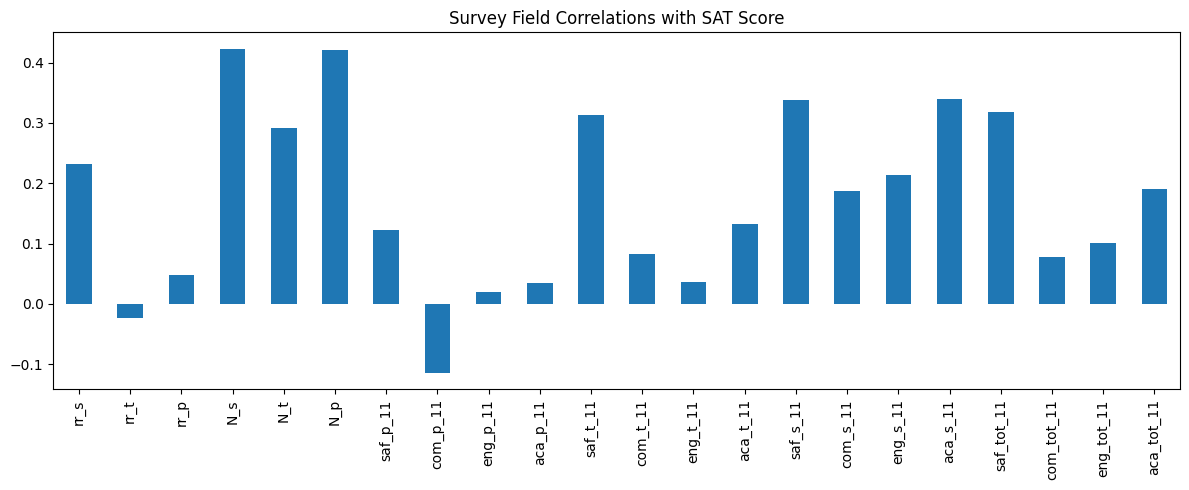

In [9]:
# Remove DBN since it's a unique identifier, not a useful numerical value for correlation
survey_fields_plot = [f for f in survey_fields if f != "DBN"]

combined.corr(numeric_only=True)["sat_score"][survey_fields_plot].plot.bar(
    title="Survey Field Correlations with SAT Score",
    figsize=(12, 5)
)
plt.tight_layout()
plt.show()

**Observations:**

- `N_s` and `N_p` (number of student/parent survey respondents) have the strongest correlations (r > 0.4), likely reflecting school size and engagement rather than a causal link to SAT performance.
- Safety scores (`saf_s_11`, `saf_t_11`, `saf_tot_11`) and academic scores (`aca_s_11`) sit around r = 0.3 - a moderate effect.
- Survey response rates (`rr_s`) show a positive correlation (~0.2): students who complete surveys may be more academically engaged generally.
- `com_p_11` (parent communication score) and `rr_t` (teacher response rate) are the only negatively correlated variables (~-0.1), though the effect is small.

## 11. Safety & SAT Scores <a id='11-safety--sat-scores'></a>

**Hypothesis:** Schools where students report higher safety scores will have higher SAT scores.

A safe environment is a prerequisite for effective teaching and learning. Schools with high perceived safety may also reflect broader differences in school culture and resources.

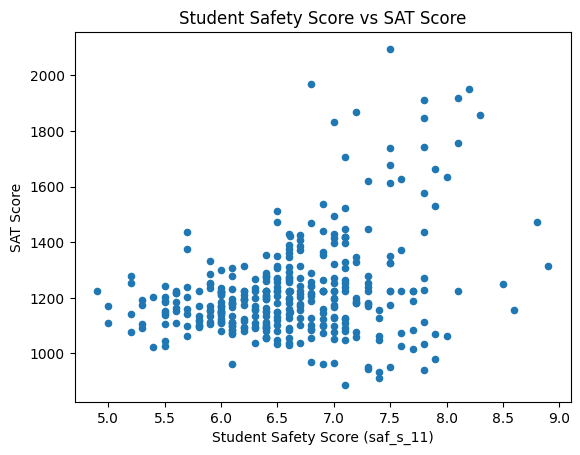

In [10]:
combined.plot.scatter("saf_s_11", "sat_score", title="Student Safety Score vs SAT Score")
plt.xlabel("Student Safety Score (saf_s_11)")
plt.ylabel("SAT Score")
plt.show()

A positive trend is visible, though with considerable spread. The cluster of schools with low safety scores spans a wide range of SAT outcomes, suggesting safety is one of several contributing factors rather than a primary driver. Hypothesis supported.

**Borough-level breakdown:**

In [11]:
boros = combined.groupby("boro").agg("mean", numeric_only=True)["saf_s_11"].sort_values(ascending=False)
print(boros.to_string())

boro
Manhattan        6.831370
Queens           6.721875
Bronx            6.606577
Staten Island    6.530000
Brooklyn         6.370755


Manhattan and Queens report the highest student safety scores; Brooklyn the lowest. This broadly aligns with socioeconomic patterns across boroughs, though borough-level averages mask significant within-borough variation.

## 12. Race & SAT Scores <a id='12-race--sat-scores'></a>

**Hypothesis:** Marginalised racial groups will have lower average SAT scores, potentially reflecting systemic barriers including language access and school resources.

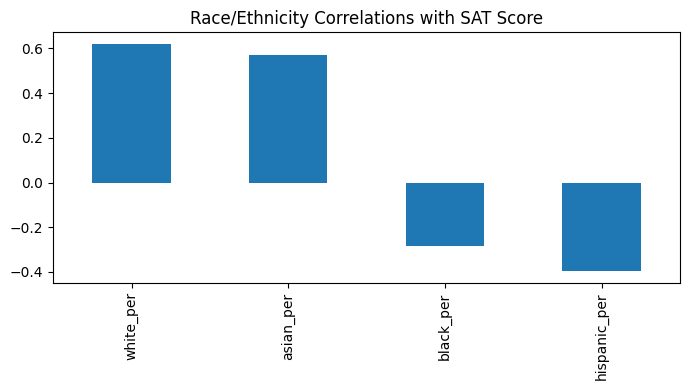

In [12]:
race_vars = ["white_per", "asian_per", "black_per", "hispanic_per"]
combined.corr(numeric_only=True)["sat_score"][race_vars].plot.bar(
    title="Race/Ethnicity Correlations with SAT Score",
    figsize=(7, 4)
)
plt.tight_layout()
plt.show()

`white_per` and `asian_per` are positively correlated with SAT scores; `hispanic_per` and `black_per` are negatively correlated. Because Asian students also score highly, the hypothesis that non-native English speakers drive lower scores is not supported as a simple explanation.

The more likely explanation is **socioeconomic confounding**: NYC neighbourhoods with higher proportions of Hispanic and Black students tend to have lower median incomes and school funding. This analysis cannot disentangle race from income without a direct socioeconomic proxy (e.g. free/reduced lunch rate).

**Hispanic percentage deep-dive:**

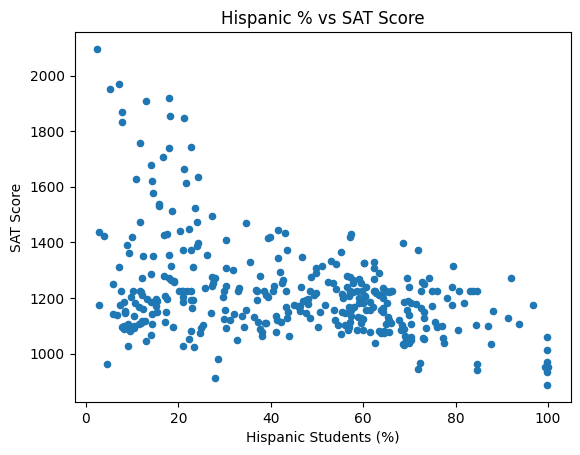

Schools with >95% Hispanic students:
44                         MANHATTAN BRIDGES HIGH SCHOOL
82      WASHINGTON HEIGHTS EXPEDITIONARY LEARNING SCHOOL
89     GREGORIO LUPERON HIGH SCHOOL FOR SCIENCE AND M...
125                  ACADEMY FOR LANGUAGE AND TECHNOLOGY
141                INTERNATIONAL SCHOOL FOR LIBERAL ARTS
176     PAN AMERICAN INTERNATIONAL HIGH SCHOOL AT MONROE
253                            MULTICULTURAL HIGH SCHOOL
286               PAN AMERICAN INTERNATIONAL HIGH SCHOOL


In [13]:
combined.plot.scatter("hispanic_per", "sat_score", title="Hispanic % vs SAT Score")
plt.xlabel("Hispanic Students (%)")
plt.ylabel("SAT Score")
plt.show()

print("Schools with >95% Hispanic students:")
print(combined[combined["hispanic_per"] > 95]["SCHOOL NAME"].to_string())

Several schools at the extreme high end of Hispanic enrollment serve **recently arrived Spanish-speaking immigrants** (e.g. Gregorio Luperón High School for Math and Science, Manhattan Bridges High School). SAT scores for these students reflect language acquisition barriers rather than academic ability, which likely inflates the negative correlation.

**High-scoring, low-Hispanic schools:**

In [14]:
print("Schools with <10% Hispanic students and SAT score >1800:")
print(combined[(combined["hispanic_per"] < 10) & (combined["sat_score"] > 1800)]["SCHOOL NAME"].to_string())

Schools with <10% Hispanic students and SAT score >1800:
37                                STUYVESANT HIGH SCHOOL
151                         BRONX HIGH SCHOOL OF SCIENCE
187                       BROOKLYN TECHNICAL HIGH SCHOOL
327    QUEENS HIGH SCHOOL FOR THE SCIENCES AT YORK CO...
356                  STATEN ISLAND TECHNICAL HIGH SCHOOL


These are **selective specialist schools** (Stuyvesant, Bronx High School of Science) with competitive admissions exams, which creates selection bias at the high end of the distribution. Their demographic composition is a consequence of admissions policy, not a cause of performance.

## 13. Gender & SAT Scores <a id='13-gender--sat-scores'></a>

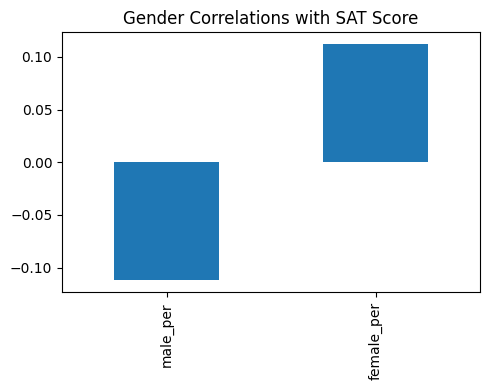

In [15]:
gender_vars = ["male_per", "female_per"]
combined.corr(numeric_only=True)["sat_score"][gender_vars].plot.bar(
    title="Gender Correlations with SAT Score",
    figsize=(5, 4)
)
plt.tight_layout()
plt.show()

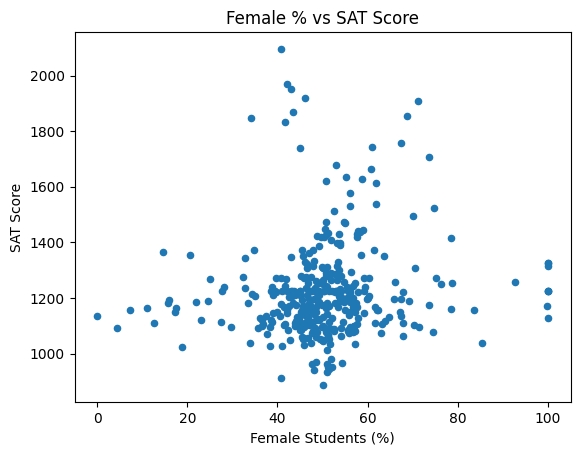

Schools with >60% female students and SAT score >1700:
5                         BARD HIGH SCHOOL EARLY COLLEGE
26                         ELEANOR ROOSEVELT HIGH SCHOOL
60                                    BEACON HIGH SCHOOL
61     FIORELLO H. LAGUARDIA HIGH SCHOOL OF MUSIC & A...
302                          TOWNSEND HARRIS HIGH SCHOOL


In [16]:
combined.plot.scatter("female_per", "sat_score", title="Female % vs SAT Score")
plt.xlabel("Female Students (%)")
plt.ylabel("SAT Score")
plt.show()

print("Schools with >60% female students and SAT score >1700:")
print(combined[(combined["female_per"] > 60) & (combined["sat_score"] > 1700)]["SCHOOL NAME"].to_string())

The scatterplot shows no meaningful trend. The small cluster of high-scoring, majority-female schools (e.g. Bard High School Early College, Eleanor Roosevelt High School) are **highly selective schools** - their gender composition reflects admissions patterns, not a causal effect of gender on SAT performance. Statistical testing (see Section 16) confirms this is the weakest predictor in the analysis.

## 14. AP Scores & SAT Scores <a id='14-ap-scores--sat-scores'></a>

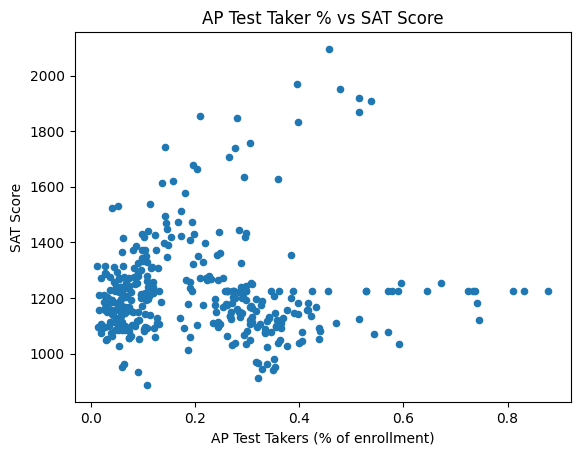

In [17]:
combined["ap_per"] = combined["AP Test Takers "] / combined["total_enrollment"]

combined.plot.scatter(x="ap_per", y="sat_score", title="AP Test Taker % vs SAT Score")
plt.xlabel("AP Test Takers (% of enrollment)")
plt.ylabel("SAT Score")
plt.show()

There is a weak positive relationship between AP participation and SAT scores. Both likely reflect a shared underlying factor: schools with a stronger academic culture tend to have higher participation in both AP exams and SAT preparation. AP participation rate is therefore better understood as an indicator of school academic culture than a direct predictor of SAT performance.

## 15. Class Size & SAT Scores <a id='15-class-size--sat-scores'></a>

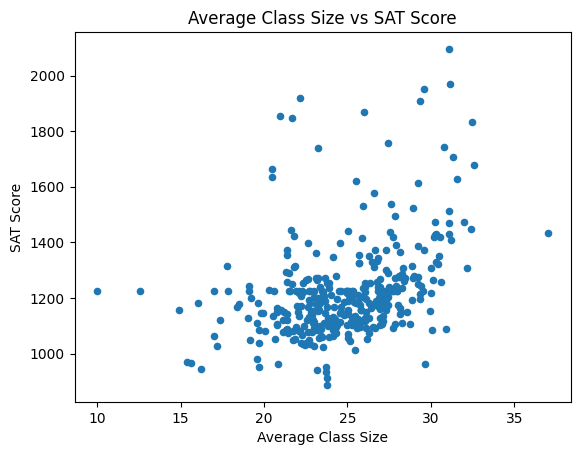

In [18]:
combined.plot.scatter(x="AVERAGE CLASS SIZE", y="sat_score", title="Average Class Size vs SAT Score")
plt.xlabel("Average Class Size")
plt.ylabel("SAT Score")
plt.show()

Counterintuitively, larger class sizes correlate positively with SAT scores. This is likely a **spurious correlation** driven by school type:

- **Oversubscribed high-performing schools** in dense urban areas naturally have larger classes due to demand.
- **Small intervention schools** - created specifically to support underperforming students - tend to have smaller classes by design, pulling down the low end of class size while also having lower SAT scores.
- **Selective specialist schools** (e.g. Stuyvesant) may have larger classes while also having the highest SAT scores.

Class size is therefore not a meaningful predictor of SAT performance on its own; school type is likely the confounding variable.

## 16. Statistical Significance <a id='16-statistical-significance'></a>

Pearson's r and r² are computed for each key variable. With 363 schools in the dataset, almost all correlations are statistically significant (p < 0.05) - including weak ones. **Effect size (r²) is therefore the more informative metric**, as it quantifies the proportion of variance in SAT scores explained by each variable.

In [19]:
variables = ["saf_s_11", "white_per", "hispanic_per", "female_per", "AVERAGE CLASS SIZE"]

print(f"{'Variable':<25} {'r':>6}  {'r²':>6}  {'p':>12}  {'Sig':>4}  {'Strength'}")
print("-" * 75)

for var in variables:
    subset = combined[[var, "sat_score"]].dropna()
    r, p = scipy.stats.pearsonr(subset[var], subset["sat_score"])
    r2 = r ** 2
    sig = "YES" if p < 0.05 else "NO"
    if abs(r) >= 0.5:
        strength = "Strong"
    elif abs(r) >= 0.3:
        strength = "Moderate"
    elif abs(r) >= 0.1:
        strength = "Weak"
    else:
        strength = "Negligible"
    print(f"{var:<25} {r:>+6.3f}  {r2:>5.1%}  {p:>12.8f}  {sig:>4}  {strength}")

Variable                       r      r²             p   Sig  Strength
---------------------------------------------------------------------------
saf_s_11                  +0.338  11.4%    0.00000000   YES  Moderate
white_per                 +0.621  38.5%    0.00000000   YES  Strong
hispanic_per              -0.397  15.8%    0.00000000   YES  Moderate
female_per                +0.112   1.3%    0.03273586   YES  Weak
AVERAGE CLASS SIZE        +0.381  14.5%    0.00000000   YES  Moderate


## 17. Summary & Conclusions <a id='17-summary--conclusions'></a>

### Key Findings

| Variable | r | r² | Interpretation |
|---|---|---|---|
| `white_per` | +0.621 | 38.5% | Strongest predictor; likely a proxy for school funding and neighbourhood wealth |
| `hispanic_per` | -0.397 | 15.8% | Moderate negative effect; inflated by immigrant-serving schools and socioeconomic factors |
| `AVERAGE CLASS SIZE` | +0.381 | 14.5% | Likely spurious; larger classes characterise oversubscribed high-performing schools |
| `saf_s_11` | +0.338 | 11.4% | Moderate positive effect; safe environments support academic performance |
| `female_per` | +0.112 | 1.3% | Negligible; not a meaningful predictor of SAT scores |

### Interpretation

Race/ethnicity composition is the strongest correlate of SAT scores in this dataset, but this almost certainly reflects **socioeconomic confounding** rather than a direct effect of race. NYC school funding is tied to property taxes and neighbourhood wealth, meaning schools in lower-income areas - which tend to serve more Black and Hispanic students - receive fewer resources. The analysis cannot separate these effects without a direct income or funding variable.

The class size finding is **counterintuitive but likely spurious**: small schools in NYC have often been created as intervention programmes for struggling students, which artificially inflates the positive correlation between class size and scores.

Gender has a negligible relationship with SAT scores at the school level. The few high-scoring majority-female schools are outliers explained by selective admissions, not gender composition.

### Limitations

- This is a **cross-sectional, correlational analysis** so no causal conclusions can be drawn.
- Missing data was imputed with column means, which may attenuate some correlations.
- The 2006 graduation cohort and 2011–2012 school year data may not reflect current conditions.
- No socioeconomic proxy variable (e.g. free/reduced lunch rate) was included, leaving the most important confound uncontrolled.

### Suggested Further Analysis

- Include `frl_percent` (free/reduced lunch) as a socioeconomic proxy and test whether race correlations weaken when controlling for it.
- Run a multiple regression to assess the combined predictive power of all variables.
- Map SAT scores by school district to identify geographic clustering.